# 05 Interactions entre candidats

Qui mentionne qui ? Réseau de mentions, lift d'engagement et concentration des flux.

## 5.1 Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

_root = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(_root))
from src.utils import (
    COLORS, DATA_RAW, CROSS_MENTIONS, LEGACY_INTERACTIONS, A5_OUT, A7_OUT, FIG_DIR,
    swiss_style, setup_mpl, load_replies, _safe_read
)
setup_mpl()
FIG_DIR.mkdir(parents=True, exist_ok=True)

cross = _safe_read(CROSS_MENTIONS)
tweets = pd.read_csv(DATA_RAW / "tweets_twitter.csv") if DATA_RAW and (DATA_RAW / "tweets_twitter.csv").exists() else None
replies = load_replies() if DATA_RAW else None
synth = _safe_read(A7_OUT / "A7_synthese_par_candidat.csv")

## 5.1 Réseau de mentions

Graphe orienté : nœuds = candidats (taille = mentions reçues), arêtes = flux de mentions. Layout gauche/droite, Grégoire au centre.

In [2]:
# Réseau mentions (orienté)
import networkx as nx
if cross is not None and len(cross) > 0:
    G = nx.from_pandas_edgelist(cross, "source_label", "target_label", edge_attr="mentions", create_using=nx.DiGraph())
    in_deg = dict(G.in_degree(weight="mentions"))
    node_sizes = [100 + in_deg.get(n, 0) * 15 for n in G.nodes()]
    pos = nx.spring_layout(G, k=2, seed=42)
    if "Gregoire" in pos or "Grégoire" in pos:
        c = "Gregoire" if "Gregoire" in G.nodes() else "Grégoire"
        pos[c] = (0, 0)
    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=[COLORS.get(n.replace("Gregoire","Grégoire"),"#888") for n in G.nodes()])
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, alpha=0.6, arrowsize=15)
    swiss_style(ax, "5.1 Réseau des mentions", source="cross_candidate_mentions")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "05_reseau_mentions.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()

## 5.2 Lift et mentions reçues

## 5.2 Matrice asymétrique

Heatmap émetteur × récepteur avec annotations dans les cellules.

In [3]:
# Heatmap émetteur x récepteur
if cross is not None and len(cross) > 0:
    mat = cross.pivot_table(index="source_label", columns="target_label", values="mentions", aggfunc="sum").fillna(0)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(mat.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    for i in range(len(mat.index)):
        for j in range(len(mat.columns)):
            v = mat.iloc[i, j]
            ax.text(j, i, int(v) if v > 0 else "", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, label="Mentions")
    swiss_style(ax, "5.2 Matrice mentions (émetteur x récepteur)", source="cross_candidate_mentions")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "05_matrice_mentions.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()

## 5.3 Mentions textuelles vs @

Regex pour détecter les noms de candidats dans le texte des tweets. Matrice des mentions textuelles vs @mentions.

In [4]:
# Mentions textuelles (noms dans le texte)
import re
name_patterns = {"Brossat": r"Brossat", "Chikirou": r"Chikirou", "Belliard": r"Belliard", "Grégoire": r"Gr[ée]goire", "Bournazel": r"Bournazel", "Dati": r"Dati", "Knafo": r"Knafo", "Mariani": r"Mariani"}
if tweets is not None and "text" in tweets.columns:
    text_ment = {}
    for _, row in tweets.iterrows():
        author = row.get("candidate", "?")
        if author == "Gregoire": author = "Grégoire"
        for target, pat in name_patterns.items():
            if target != author and re.search(pat, str(row.get("text","")), re.I):
                text_ment[(author, target)] = text_ment.get((author, target), 0) + 1
    tm_df = pd.DataFrame([{"source":k[0],"target":k[1],"count":v} for k,v in text_ment.items()])
    print("Mentions textuelles (hors @):", tm_df.head(10).to_string() if len(tm_df)>0 else "Aucune")

Mentions textuelles (hors @):      source     target  count
0  Belliard       Dati     85
1  Belliard   Grégoire     16
2  Belliard      Knafo     11
3  Belliard  Bournazel      6
4  Belliard    Brossat      6
5  Belliard    Mariani      1
6  Grégoire       Dati    133
7  Grégoire    Mariani      3
8  Grégoire      Knafo     17
9  Grégoire    Brossat     11


## 5.5 Contenu des interactions

Top 15 posts cross-candidats les plus engageants. Catégorisation : alliance, débat, attaque, programme.

In [5]:
# Top 15 posts cross-candidats par engagement (tweets mentionnant un autre candidat)
if tweets is not None:
    tw = tweets.copy()
    tw["engagement"] = tw["likes"].fillna(0) + tw["comments"].fillna(0) + tw["shares"].fillna(0)
    cross_posts = []
    for _, row in tw.iterrows():
        author = row.get("candidate", "")
        if author == "Gregoire": author = "Grégoire"
        txt = str(row.get("text", ""))
        for target, pat in name_patterns.items():
            if target != author and re.search(pat, txt, re.I):
                cross_posts.append({"candidate": author, "mentions": target, "text": txt[:100]+"...", "engagement": row["engagement"]})
                break
    if cross_posts:
        cp_df = pd.DataFrame(cross_posts)
        top15 = cp_df.nlargest(15, "engagement")
        display(top15)

,candidate,mentions,text,engagement
601,Knafo,Grégoire,🔴 Chaque foyer français paye un abonnement for...,206950
592,Knafo,Grégoire,"Monsieur Grégoire, je note que je suis « votre...",18160
600,Knafo,Dati,🚨J'apprends que la Fondation Bill Gates recrut...,17812
591,Knafo,Grégoire,Quelle honte @egregoire !\nC'est un militant R...,14621
359,Brossat,Knafo,🇫🇷🗳️ - « Les NÉGROÏDES pullulent comme des caf...,13990
613,Knafo,Chikirou,12% ! Désormais devant La France Insoumise de ...,13707
596,Knafo,Dati,Ces journalistes de France Info prétendent que...,13471
598,Knafo,Grégoire,"Monsieur @egregoire, si votre promesse est de ...",12731
595,Knafo,Dati,"Le ministère de la Culture, c'est 8 milliards ...",12535
594,Knafo,Dati,Mes adversaires dans cette campagne ne sont ni...,12532


## 5.6 Qui attaque qui

Matrice émetteur × récepteur colorée par ton (positif/négatif/neutre) selon le sentiment des replies ou du contenu.

In [6]:
# Matrice ton : agrégation sentiment des replies par paire (candidat ciblé x auteur du tweet)
# Simplifié : on utilise le cross mentions et on colorie par ratio hostilité (si replies dispo)
if cross is not None and replies is not None:
    rep_sent = replies.groupby("candidate").apply(lambda g: (g["sentiment"].isin(["HOSTILITÉ","HOSTILITE"])).mean()).to_dict()
    cross_ton = cross.copy()
    cross_ton["target_norm"] = cross_ton["target_label"].replace("Gregoire","Grégoire")
    cross_ton["ton"] = cross_ton["target_norm"].map(rep_sent)
    pivot_ton = cross_ton.pivot_table(index="source_label", columns="target_label", values="ton", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pivot_ton.fillna(0).values, cmap="RdYlGn_r", vmin=0, vmax=0.5, aspect="auto")
    ax.set_xticks(range(len(pivot_ton.columns)))
    ax.set_xticklabels(pivot_ton.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot_ton.index)))
    ax.set_yticklabels(pivot_ton.index)
    plt.colorbar(im, ax=ax, label="% hostilité replies")
    swiss_style(ax, "5.6 Ton des réponses par candidat ciblé", source="cross_mentions + replies")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "05_qui_attaque.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()

## 5.7 Centralité

Degré entrant/sortant, betweenness, PageRank. Tableau et interprétation.

In [7]:
# Centralité : degré entrant/sortant, betweenness, PageRank
if cross is not None and len(cross) > 0:
    G = nx.from_pandas_edgelist(cross, "source_label", "target_label", edge_attr="mentions", create_using=nx.DiGraph())
    in_d = dict(G.in_degree(weight="mentions"))
    out_d = dict(G.out_degree(weight="mentions"))
    bet = nx.betweenness_centrality(G, weight="mentions")
    pr = nx.pagerank(G, weight="mentions")
    cent_df = pd.DataFrame({
        "deg_in": in_d,
        "deg_out": out_d,
        "betweenness": bet,
        "pagerank": pr
    })
    display(cent_df.sort_values("pagerank", ascending=False))

,deg_in,deg_out,betweenness,pagerank
Gregoire,80,20,0.238095,0.424412
Brossat,14,31,0.095238,0.201157
Dati,33,5,0.095238,0.177204
Belliard,7,20,0.309524,0.115716
Bournazel,5,17,0.000000,0.025262
Chikirou,0,40,0.000000,0.018750
Mariani,0,4,0.000000,0.018750
Knafo,0,2,0.000000,0.018750


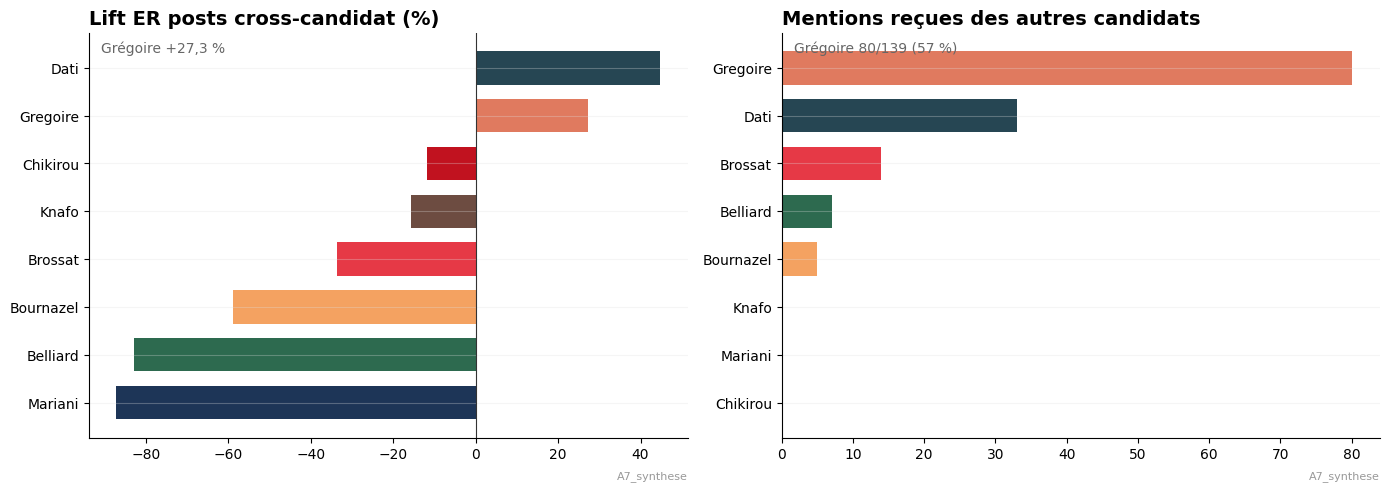

In [9]:
if synth is not None and "lift_pct" in synth.columns and "mentions_recues" in synth.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    s = synth.sort_values("lift_pct", ascending=True)
    axes[0].barh(s["key"], s["lift_pct"], color=[COLORS.get(k, "#333") for k in s["key"]], height=0.7)
    axes[0].axvline(0, color="#333", lw=0.8)
    swiss_style(axes[0], "Lift ER posts cross-candidat (%)", "Grégoire +27,3 %", "A7_synthese")
    s2 = synth.sort_values("mentions_recues", ascending=True)
    axes[1].barh(s2["key"], s2["mentions_recues"], color=[COLORS.get(k, "#333") for k in s2["key"]], height=0.7)
    swiss_style(axes[1], "Mentions reçues des autres candidats", "Grégoire 80/139 (57 %)", "A7_synthese")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "05_lift_mentions.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 5.3 Synthèse

Grégoire concentre 80 des 139 mentions cross-candidats (57 %). C'est le hub principal : on parle de lui bien plus qu'il ne parle des autres. Bournazel (+47,5 %) et Dati (+35,5 %) ont un fort lift, signe que leurs contenus mentionnant d'autres candidats déclenchent plus d'engagement. À l'inverse, Belliard (-82,9 %) et Brossat (-33,7 %) voient leur ER chuter quand ils mentionnent la concurrence.